In [4]:
import pandas as pd


X = [1,2,2,3,4,4,5,6]
print(X)
Y =[2,  3, 4, 4, 4,  5, 6, 7]

vista_tabla = {"x": X,
             "y":Y,
             }

print(vista_tabla)
df = pd.DataFrame(vista_tabla)

df

[1, 2, 2, 3, 4, 4, 5, 6]
{'x': [1, 2, 2, 3, 4, 4, 5, 6], 'y': [2, 3, 4, 4, 4, 5, 6, 7]}


,x,y
0,1,2
1,2,3
2,2,4
3,3,4
4,4,4
5,4,5
6,5,6
7,6,7


In [6]:
df['XY'] = df['x'] * (df['y'])
df

,x,y,XY
0,1,2,2
1,2,3,6
2,2,4,8
3,3,4,12
4,4,4,16
5,4,5,20
6,5,6,30
7,6,7,42


In [7]:
df['Xala2'] = df['x'] **2
df

,x,y,XY,Xala2
0,1,2,2,1
1,2,3,6,4
2,2,4,8,4
3,3,4,12,9
4,4,4,16,16
5,4,5,20,16
6,5,6,30,25
7,6,7,42,36


In [8]:
df.loc['Column_Total'] = df.sum(numeric_only=True)
df

,x,y,XY,Xala2
0,1,2,2,1
1,2,3,6,4
2,2,4,8,4
3,3,4,12,9
4,4,4,16,16
5,4,5,20,16
6,5,6,30,25
7,6,7,42,36
Column_Total,27,35,136,111


## Regresión Lineal y Matriz de Correlación

### Regresión Lineal
La **regresión lineal** es un modelo estadístico que busca establecer una relación lineal entre una variable dependiente (o de respuesta) y una o más variables independientes (o predictoras). En su forma más simple (regresión lineal simple), se modela la relación entre dos variables como una línea recta: $Y = \beta_0 + \beta_1X + \epsilon$, donde:
- $Y$ es la variable dependiente.
- $X$ es la variable independiente.
- $\beta_0$ es el intercepto (el valor de $Y$ cuando $X$ es 0).
- $\beta_1$ es la pendiente (cuánto cambia $Y$ por cada unidad de cambio en $X$).
- $\epsilon$ es el término de error, que representa la variabilidad no explicada por el modelo.

El objetivo es encontrar los valores de $\beta_0$ y $\beta_1$ que mejor ajusten la línea a los datos, minimizando la distancia entre los puntos de datos y la línea.

### Matriz de Correlación
Una **matriz de correlación** es una tabla que muestra los coeficientes de correlación entre múltiples variables. Cada elemento $(i, j)$ de la matriz representa la correlación entre la variable $i$ y la variable $j$. El coeficiente de correlación más común es el coeficiente de correlación de Pearson, que mide la fuerza y dirección de una relación lineal entre dos variables.

- Un valor cercano a `1` indica una correlación positiva fuerte (cuando una variable aumenta, la otra también).
- Un valor cercano a `-1` indica una correlación negativa fuerte (cuando una variable aumenta, la otra disminuye).
- Un valor cercano a `0` indica una correlación lineal débil o inexistente.

En el contexto de la regresión lineal, la matriz de correlación nos ayuda a identificar rápidamente qué variables independientes tienen una relación lineal fuerte con la variable dependiente, lo que puede ser útil para seleccionar las características para nuestro modelo.

Matriz de Correlación:


,x,y,XY,Xala2
x,1.000000,0.948352,0.968374,0.978174
y,0.948352,1.000000,0.967721,0.941999
XY,0.968374,0.967721,1.000000,0.993277
Xala2,0.978174,0.941999,0.993277,1.000000


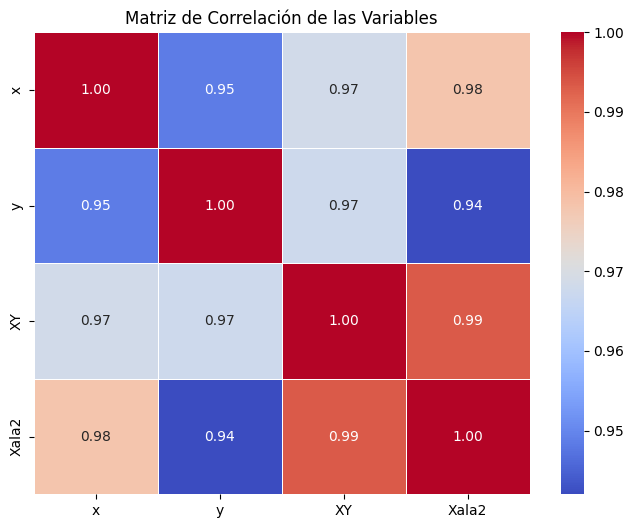

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Excluimos la fila 'Column_Total' ya que es un agregado y no un punto de datos real para la correlación.
df_numeric = df.drop('Column_Total', axis=0)

# Calculamos la matriz de correlación
correlation_matrix = df_numeric.corr()
print("Matriz de Correlación:")
display(correlation_matrix)

# Visualizamos la matriz de correlación usando un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de las Variables')
plt.show()

En la matriz de correlación y el mapa de calor, podemos observar las relaciones entre las variables:
- `x` y `y` tienen una correlación positiva muy fuerte (cercana a 1), lo que sugiere que cuando `x` aumenta, `y` tiende a aumentar.
- `XY` y `Xala2` también muestran correlaciones fuertes con `x` e `y`, lo cual es esperado ya que son derivadas de estas variables.

Ahora, vamos a realizar una regresión lineal simple para modelar la relación entre `x` (variable independiente) e `y` (variable dependiente).

Intercepto (β0): 1.34
Pendiente (β1): 0.90


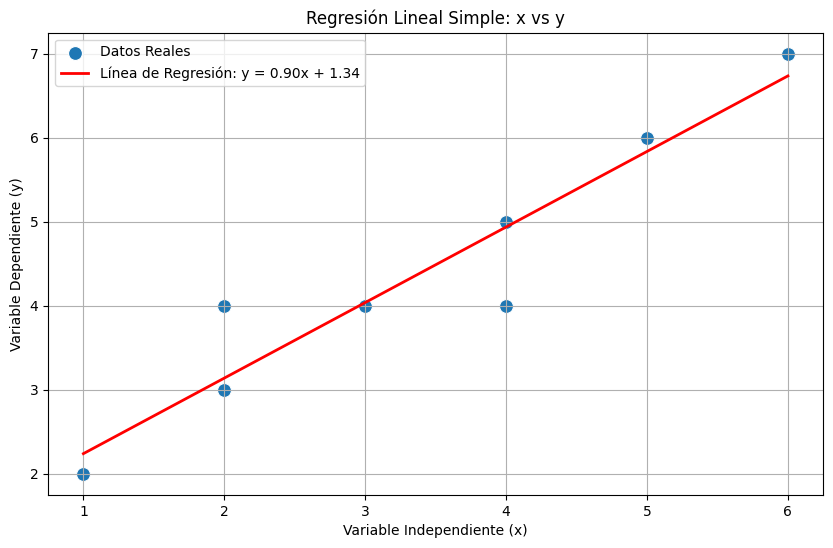

In [10]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Preparamos los datos para el modelo de regresión lineal
# X debe ser un array 2D para scikit-learn
X = df_numeric[['x']].values
y = df_numeric['y'].values

# Creamos y ajustamos el modelo de regresión lineal
model = LinearRegression()
model.fit(X, y)

# Obtenemos los coeficientes del modelo
intercept = model.intercept_
slope = model.coef_[0]

print(f"Intercepto (\u03B20): {intercept:.2f}")
print(f"Pendiente (\u03B21): {slope:.2f}")

# Realizamos predicciones
y_pred = model.predict(X)

# Visualizamos los datos y la línea de regresión
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_numeric['x'], y=df_numeric['y'], s=100, label='Datos Reales')
plt.plot(df_numeric['x'], y_pred, color='red', linewidth=2, label=f'Línea de Regresión: y = {slope:.2f}x + {intercept:.2f}')
plt.title('Regresión Lineal Simple: x vs y')
plt.xlabel('Variable Independiente (x)')
plt.ylabel('Variable Dependiente (y)')
plt.legend()
plt.grid(True)
plt.show()

En el gráfico final, puedes ver los puntos de tus datos originales y la línea roja que representa la regresión lineal. Esta línea es el mejor ajuste lineal que describe cómo `y` cambia en relación con `x`, basándose en los coeficientes que calculamos (intercepto y pendiente). La alta correlación positiva que vimos en la matriz se refleja en una pendiente positiva de esta línea.